<div style="background:linear-gradient(135deg,#0f2027 0%,#203a43 50%,#2c5364 100%);padding:32px 34px;border-radius:16px;
            box-shadow:0 8px 24px rgba(0,0,0,0.18);font-family:'Segoe UI',Roboto,sans-serif;">
  <h1 style="margin:0;color:#ffffff;font-size:34px;letter-spacing:-0.5px;">🚀&nbsp; Getting Started with <code>pinnlab</code></h1>
  <p style="margin:12px 0 0;color:#eaf6ff;font-size:17px;line-height:1.5;max-width:760px;">Your first five minutes with the library: what a Physics-Informed Neural Network is, how this package is organised, and a tiny end-to-end solve you can run on a laptop CPU.</p>
</div>

<div><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">level</span><span style="background:#1e9e54;color:#fff;padding:4px 8px;">start here</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">topic</span><span style="background:#1a73e8;color:#fff;padding:4px 8px;">orientation</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">runtime</span><span style="background:#7b3fe4;color:#fff;padding:4px 8px;">~1 min · CPU</span></span></div>

Welcome! 👋 This notebook is the front door to the `pinnlab` example gallery. By the end you will have
trained a real PINN and you'll know where to go next.

**What is a PINN?** A neural network that solves a differential equation by being penalised whenever
it *violates* that equation — the physics is baked into the loss function, so you need little or no
labelled data.

<div style="background:#f6f8fa;border:1px solid #e1e4e8;border-radius:10px;padding:18px 24px;
            font-family:'Segoe UI',sans-serif;">
  <b style="font-size:15px;">📑 Table of Contents</b>
  <ol style="margin:10px 0 0;padding-left:20px;font-size:14px;line-height:1.6;">
  <li style="margin:3px 0;"><a href="#install" style="color:#1a73e8;text-decoration:none;">1 · Installation</a></li>
  <li style="margin:3px 0;"><a href="#setup" style="color:#1a73e8;text-decoration:none;">2 · Setup & Sanity Check</a></li>
  <li style="margin:3px 0;"><a href="#anatomy" style="color:#1a73e8;text-decoration:none;">3 · Anatomy of the Library</a></li>
  <li style="margin:3px 0;"><a href="#first" style="color:#1a73e8;text-decoration:none;">4 · Your First Solve</a></li>
  <li style="margin:3px 0;"><a href="#look" style="color:#1a73e8;text-decoration:none;">5 · A First Look at the Result</a></li>
  <li style="margin:3px 0;"><a href="#next" style="color:#1a73e8;text-decoration:none;">6 · Where to Go Next</a></li>
  </ol>
</div>

<a id="install"></a>

## 1 · Installation

From PyPI:

```bash
pip install pinnlab
```

That brings in PyTorch, NumPy, PyYAML and tqdm -- the solver and nothing else.
`import pinnlab` does not touch matplotlib.

**The notebooks in this gallery plot, so they need the `viz` extra:**

```bash
pip install "pinnlab[viz]"
```

which adds matplotlib, seaborn, Plotly and SciPy. Without it the library still
solves PDEs; asking for a plotting helper raises an `AttributeError` naming the
extra rather than failing somewhere less obvious. seaborn only sets the default
palette, and SciPy unlocks a few advanced metrics and samplers that warn rather
than fail when absent.

To work on the library itself, install it in editable mode from a clone
instead:

```bash
pip install -e ".[dev,viz]"
```

The distribution is `pinnlab`, not `pinn`: the name `pinn` on PyPI belongs to
an unrelated REST-API client. The import name matches the distribution, so
`import pinnlab` either way.

<a id="setup"></a>

## 2 · Setup & Sanity Check

Run the cell below — it imports everything and confirms your environment.

In [1]:
# --- Environment setup -------------------------------------------------------
import warnings, logging, os
warnings.filterwarnings("ignore")
logging.getLogger("pinnlab").setLevel(logging.ERROR)          # quiet library logs

# Disable tqdm progress bars for clean, static notebook output
from functools import partialmethod
import tqdm
tqdm.tqdm.__init__ = partialmethod(tqdm.tqdm.__init__, disable=True)

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl

# A clean, consistent "Kaggle" plotting theme ---------------------------------
plt.rcParams.update({
    "figure.figsize":   (9, 5),
    "figure.dpi":       110,
    "savefig.dpi":      110,
    "font.size":        11,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   11,
    "axes.edgecolor":   "#cccccc",
    "axes.grid":        True,
    "grid.color":       "#e6e6e6",
    "grid.linewidth":   0.8,
    "axes.axisbelow":   True,
    "legend.frameon":   True,
    "legend.framealpha":0.9,
})
ACCENT, ACCENT2, ACCENT3 = "#1a73e8", "#d6336c", "#1e9e54"

# Reproducibility -------------------------------------------------------------
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

import pinnlab
print(f"pinnlab      : {pinnlab.__version__}")
print(f"PyTorch      : {torch.__version__}")
print(f"Compute      : {DEVICE.upper()}")

pinnlab      : 0.5.0
PyTorch      : 2.11.0+cpu
Compute      : CPU


<a id="anatomy"></a>

## 3 · Anatomy of the Library

The package is organised around a few clear ideas:

| Module | What lives there |
|---|---|
| `pinnlab.models` | Network architectures (`MLP`, Fourier-feature, multi-scale, …) |
| `pinnlab.solvers` | Ready-made PDE solvers (`ContinuousPINN`, Navier–Stokes, …) |
| `pinnlab.problems` | Composable problem definitions (`HeatProblem`, `AllenCahnProblem`, …) |
| `pinnlab.geometry` · `pinnlab.constraints` · `pinnlab.residuals` | The pieces a problem is built from |
| `pinnlab.sampling` | Collocation strategies (Latin-Hypercube, importance, active learning) |
| `pinnlab.training` | `Trainer`, plus adaptive weighting, curriculum and multi-scale utilities |
| `pinnlab.transfer` | Transfer learning & pre-training |
| `pinnlab.utils` | Metrics, checkpointing, visualization, profiling |

There are **two ways in**, and they coexist deliberately:

- A **solver** (`ContinuousPINN`, `HeatPINN`, …) plus a **`TrainConfig`**. One object owns both the
  equation and its training loop. Shortest path to a result, and what this notebook uses below.
- A **problem** (`AllenCahnProblem`, …) plus a **`Trainer`** and a **`TrainerConfig`**. The equation and
  the optimisation are separate objects, so you can change either without touching the other — which
  matters as soon as you want to compare strategies rather than just get an answer.

The solvers are increasingly built on the composable path internally, so the two agree on physics.
[`basic/06_composable_api`](basic/06_composable_api.ipynb) shows the second style and why the split
earns its keep.

<a id="first"></a>

## 4 · Your First Solve

We'll solve the Burgers equation in just a handful of lines. (The dedicated [Burgers notebook](basic/01_burgers_equation.ipynb) explains every step in depth.)

In [2]:
from pinnlab.models import MLP
from pinnlab.solvers.raissi_improved import (
    BurgersConfig, TrainConfig, ContinuousPINN, burgers_residual)

cfg   = BurgersConfig()                                   # the PDE + domain
model = MLP(in_dim=2, hidden_layers=4, width=32, out_dim=1)
pinn  = ContinuousPINN(model=model, device=DEVICE,
                       pde_residual_fn=burgers_residual, cfg_burgers=cfg)

history = pinn.train(TrainConfig(
    n_u0=100, n_bc=100, n_f=1_000,
    adam_steps=1_200, lbfgs_max_iter=0, seed=SEED, track_losses=True,
), weights=(10.0, 1.0, 1.0))

print(f"Final loss: {history['total'][-1]:.3e}")

Final loss: 3.302e-01


<a id="look"></a>

## 5 · A First Look at the Result

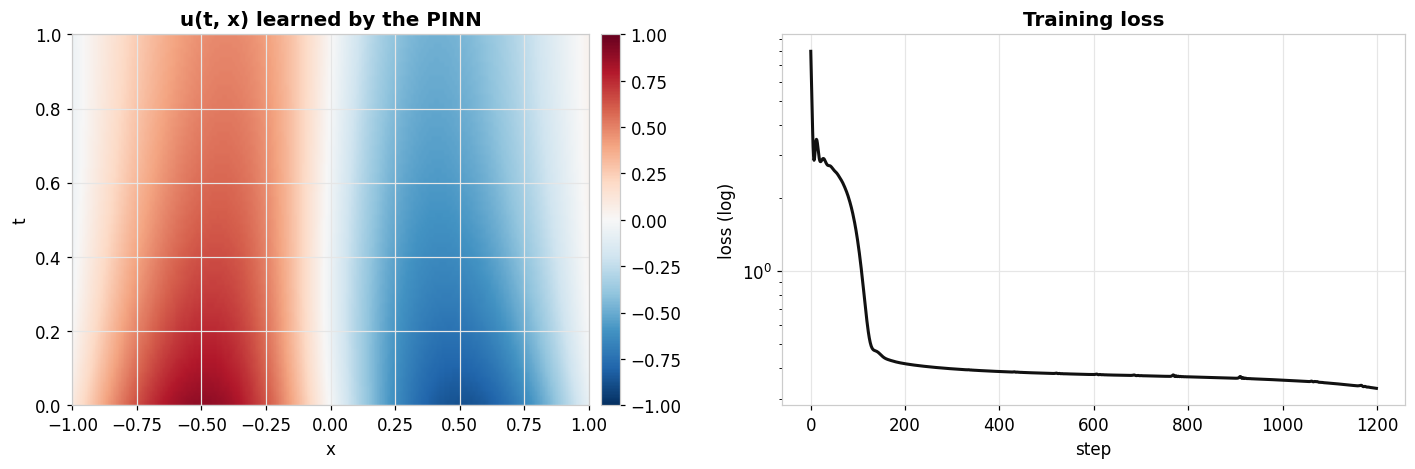

In [3]:
nt, nx = 80, 200
t_grid = np.linspace(cfg.tmin, cfg.tmax, nt, dtype=np.float32)
x_grid = np.linspace(cfg.xmin, cfg.xmax, nx, dtype=np.float32)
TT, XX = np.meshgrid(t_grid, x_grid, indexing="ij")
U = pinn.predict(TT, XX)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.4))
im = a1.imshow(U, extent=[cfg.xmin, cfg.xmax, cfg.tmin, cfg.tmax], origin="lower",
               aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
a1.set(title="u(t, x) learned by the PINN", xlabel="x", ylabel="t")
fig.colorbar(im, ax=a1, pad=0.02)

a2.plot(history["total"], color="#111", lw=2)
a2.set_yscale("log"); a2.set(title="Training loss", xlabel="step", ylabel="loss (log)")
plt.tight_layout(); plt.show()

<div style="background:#e9f9ee;border-left:5px solid #1e9e54;border-radius:8px;
            padding:14px 18px;margin:6px 0;font-family:'Segoe UI',sans-serif;font-size:14px;line-height:1.6;">
  <b>✅ Tip.</b> That's a PDE solved with deep learning — no mesh, no solver matrix, just gradient descent on a physics loss. 🎉
</div>

<a id="next"></a>

## 6 · Where to Go Next

| If you want to… | Open |
|---|---|
| Understand every step of a PINN | [`basic/01_burgers_equation`](basic/01_burgers_equation.ipynb) |
| Write your own PDE residual | [`basic/02_allen_cahn`](basic/02_allen_cahn.ipynb) · [`basic/03_custom_pde`](basic/03_custom_pde.ipynb) |
| Separate the equation from the optimisation | [`basic/06_composable_api`](basic/06_composable_api.ipynb) |
| See the visualization toolkit | [`00_demo_visualization`](00_demo_visualization.ipynb) |
| Sample smarter & measure error | [`02_sampling_and_metrics`](02_sampling_and_metrics.ipynb) |
| Recover unknown parameters | [`advanced/03_inverse_problems`](advanced/03_inverse_problems.ipynb) |
| Quantify uncertainty | [`advanced/05_uncertainty_quantification`](advanced/05_uncertainty_quantification.ipynb) |
| Benchmark methods | [`benchmarks/`](benchmarks/) |

### 📚 References

1. Raissi, M., Perdikaris, P., & Karniadakis, G. E. (2019). *Physics-informed neural networks*. Journal of Computational Physics, 378, 686–707.

<div style="background:#0d1117;border-radius:12px;padding:22px 26px;color:#c9d1d9;
            font-family:'Segoe UI',sans-serif;font-size:13px;line-height:1.6;">
  <b style="color:#fff;font-size:15px;">Thanks for reading! 🙌</b><br>
  This notebook is part of the <code>pinnlab</code> example gallery. Explore the companion notebooks in
  <code>notebooks/basic</code>, <code>notebooks/advanced</code>, and <code>notebooks/benchmarks</code>
  for more physics-informed deep-learning recipes.
</div>